In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from firthlogist import FirthLogisticRegression
from sklearn.utils.validation import check_X_y
import warnings

# Opening cleaned PAROS dataset

In [2]:
CURRENT_DIRECTORY = Path.cwd().resolve()

# Find project root that contains datasets
PROJECT_ROOT = next(
    p for p in [CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents]
    if (p / "datasets").exists()
)

CLEANED_DATASET_PATH = PROJECT_ROOT / "datasets" / "PAROS_Dataset_Cleaned.csv"

if not CLEANED_DATASET_PATH.exists():
    raise FileNotFoundError(f"Cleaned dataset not found: {CLEANED_DATASET_PATH}")

df = pd.read_csv(CLEANED_DATASET_PATH)
print(f"Loaded cleaned PAROS dataset: {df.shape}")
display(df.head(3))


Loaded cleaned PAROS dataset: (2039, 71)


,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Age,Age Modifier,Gender,Race,...,Outcome of patient,Patient status,Date of Discharge or Death,Patient neurological status - Cerebral,Patient neurological status - Overall,Patient neurological status - Unknown,Year,Call_Time,Shock_Time,Time_to_Defib
0,Ems,2014-01-01,238889.0,NaN,Transport Center,Dhoby Ghaut Mrt Level B1,59,Years,Male,Chinese,...,Died In Ed,NaN,NaN,NaN,5.0,NaN,2014,2026-04-06 22:28:12,2026-04-06 22:39:17,11.083333
1,Ems,2014-01-05,272018.0,NaN,Public/Commercial Building,Level 2,66,Years,Male,Chinese,...,Died In Ed,NaN,NaN,NaN,5.0,NaN,2014,2026-04-06 15:00:42,2026-04-06 15:16:49,16.116667
2,Ems,2014-01-07,760105.0,NaN,Street/Highway,Level 1,80,Years,Male,Indian,...,Admitted,Remains In Hospital At 30Th Day Post Arrest,NaN,4.0,4.0,NaN,2014,2026-04-06 12:05:46,2026-04-06 12:14:08,8.366667


In [3]:
# ==========================================
# TIME-TO-FIRST-SHOCK CALCULATION
# ==========================================

def get_correct_shock_time(row):
    bystander_shock_cols = [
        'Defibrillation performed by - Bystander - Healthcare provider',
        'Defibrillation performed by - Bystander - Lay Person',
        'Defibrillation performed by - Bystander - Family'
    ]
    bystander_delivered = False
    for col in bystander_shock_cols:
        if col in df.columns and pd.notna(row.get(col)):
            if str(row[col]).lower() in ['yes', '1', 'true']:
                bystander_delivered = True
                break
    shock_time_col = 'Time of first shock given'
    if shock_time_col not in df.columns:
        return np.nan
    shock_time = pd.to_datetime(row[shock_time_col], errors='coerce', format='mixed')
    if bystander_delivered and pd.isna(shock_time):
        return np.nan
    return shock_time

In [4]:
call_time_col = 'Time call received at dispatch center'
df['Call_Time_DT'] = pd.to_datetime(df[call_time_col], errors='coerce', format='mixed')
df['Shock_Time_Corrected'] = df.apply(get_correct_shock_time, axis=1)
df['Time_to_Defib_Corrected'] = (df['Shock_Time_Corrected'] - df['Call_Time_DT']).dt.total_seconds() / 60
df.loc[df['Time_to_Defib_Corrected'] < 0, 'Time_to_Defib_Corrected'] = np.nan
df.loc[df['Time_to_Defib_Corrected'] > 60, 'Time_to_Defib_Corrected'] = np.nan

In [5]:
# Outcome: Strict neurological survival (CPC 1‑2 at 30 days)
outcome_cols = ['Outcome of patient', 'Patient status', 'Final status at scene']
available_cols = [col for col in outcome_cols if col in df.columns]
df['Outcome_String'] = df[available_cols].astype(str).agg(' '.join, axis=1)
survival_regex = r'Discharged Alive|Remains In Hospital At 30Th Day'
is_survivor = df['Outcome_String'].str.contains(survival_regex, case=False, regex=True)
is_good_neuro = df['Patient neurological status - Overall'].isin([1.0, 2.0])
df['Outcome_Strict'] = (is_survivor & is_good_neuro).astype(int)

In [6]:
# Covariates
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Male'] = (df['Gender'] == 'Male').astype(int)
df['Witnessed'] = df['Arrest witnessed by'].notna().astype(int)
df['Bystander_CPR'] = (df['Bystander CPR'] == 'Yes').astype(int)
public_locations = ['Public/Commercial Building', 'Street/Highway', 'Transport Center', 'Recreation/Sport', 'Industrial/Construction']
df['Public_Location'] = df['Location Type'].isin(public_locations).astype(int)

In [7]:
# Keep complete cases
model_vars = ['Outcome_Strict', 'Time_to_Defib_Corrected', 'Age', 'Male', 'Witnessed', 'Bystander_CPR', 'Public_Location']
df_clean = df.dropna(subset=model_vars).copy()
print(f"Analytic cohort size: {len(df_clean)}")
print(f"Number of good neurological outcomes: {df_clean['Outcome_Strict'].sum()}")

Analytic cohort size: 2024
Number of good neurological outcomes: 250


# 0. Patch FirthLogisticRegression for scikit‑learn compatibility


In [8]:
def patched_validate(self, X, y, **kwargs):
    from sklearn.utils.validation import check_X_y
    return check_X_y(X, y, **kwargs)
FirthLogisticRegression._validate_data = patched_validate

# 1. Scale continuous covariates (Age)


In [9]:
from sklearn.preprocessing import StandardScaler
scaler_age = StandardScaler()
df_clean['Age_scaled'] = scaler_age.fit_transform(df_clean[['Age']])
covariates_scaled = ['Age_scaled', 'Male', 'Witnessed', 'Bystander_CPR', 'Public_Location']

# 2. Piecewise Firth logistic regression – grid search for τ


In [10]:
from sklearn.linear_model import LogisticRegression

def find_optimal_tau_robust(df, time_col, outcome_col, covariate_cols, tau_candidates, C=0.1):
    best_tau = None
    max_ll = -np.inf
    for tau in tau_candidates:
        X_early = np.clip(df[time_col], a_min=None, a_max=tau)
        X_late  = np.clip(df[time_col] - tau, a_min=0, a_max=None)
        if np.std(X_early) < 1e-8 or np.std(X_late) < 1e-8:
            continue
        X = np.column_stack([X_early, X_late] + [df[c].values for c in covariate_cols])
        # Standardize features for numerical stability
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        y = df[outcome_col].values
        model = LogisticRegression(penalty='l2', C=C, solver='lbfgs', max_iter=1000)
        try:
            model.fit(X_scaled, y)
            pred_prob = model.predict_proba(X_scaled)[:, 1]
            pred_prob = np.clip(pred_prob, 1e-15, 1-1e-15)
            ll = np.sum(y * np.log(pred_prob) + (1-y) * np.log(1-pred_prob))
            if ll > max_ll:
                max_ll = ll
                best_tau = tau
                print(f"τ = {tau:.1f} -> ll = {ll:.2f} (new best)")
            else:
                print(f"τ = {tau:.1f} -> ll = {ll:.2f}")
        except Exception as e:
            print(f"τ = {tau:.1f} FAILED: {str(e)[:50]}")
            continue
    return best_tau

tau_grid = np.arange(1.0, 20.1, 0.2)
print("\n--- Grid search for optimal breakpoint τ (adjusted model, robust) ---")
optimal_tau = find_optimal_tau_robust(df_clean, 'Time_to_Defib_Corrected', 'Outcome_Strict',
                                      covariates_scaled, tau_grid, C=0.1)
if optimal_tau is None:
    raise RuntimeError("No stable τ found – try extending grid or increasing C.")
print(f"Optimal change point τ = {optimal_tau:.2f} minutes")


--- Grid search for optimal breakpoint τ (adjusted model, robust) ---
τ = 1.0 -> ll = -683.81 (new best)
τ = 1.2 -> ll = -683.81 (new best)
τ = 1.4 -> ll = -683.81 (new best)
τ = 1.6 -> ll = -683.81 (new best)
τ = 1.8 -> ll = -683.98
τ = 2.0 -> ll = -684.16
τ = 2.2 -> ll = -684.24
τ = 2.4 -> ll = -684.25
τ = 2.6 -> ll = -684.19
τ = 2.8 -> ll = -684.15
τ = 3.0 -> ll = -684.13
τ = 3.2 -> ll = -684.18
τ = 3.4 -> ll = -684.25
τ = 3.6 -> ll = -684.28
τ = 3.8 -> ll = -684.31
τ = 4.0 -> ll = -684.33
τ = 4.2 -> ll = -684.35
τ = 4.4 -> ll = -684.36
τ = 4.6 -> ll = -684.35
τ = 4.8 -> ll = -684.34
τ = 5.0 -> ll = -684.33
τ = 5.2 -> ll = -684.30
τ = 5.4 -> ll = -684.23
τ = 5.6 -> ll = -684.17
τ = 5.8 -> ll = -684.13
τ = 6.0 -> ll = -684.08
τ = 6.2 -> ll = -684.03
τ = 6.4 -> ll = -683.99
τ = 6.6 -> ll = -683.98
τ = 6.8 -> ll = -683.95
τ = 7.0 -> ll = -683.96
τ = 7.2 -> ll = -684.03
τ = 7.4 -> ll = -684.13
τ = 7.6 -> ll = -684.19
τ = 7.8 -> ll = -684.30
τ = 8.0 -> ll = -684.41
τ = 8.2 -> ll = -684.

# 3. Final model at optimal τ


In [11]:
X_early_final = np.clip(df_clean['Time_to_Defib_Corrected'], a_min=None, a_max=optimal_tau)
X_late_final  = np.clip(df_clean['Time_to_Defib_Corrected'] - optimal_tau, a_min=0, a_max=None)
X_cov_final = df_clean[covariates_scaled].values
X_final = np.column_stack([X_early_final, X_late_final, X_cov_final])
y_final = df_clean['Outcome_Strict'].values

# Standardize all features for final model
scaler_final = StandardScaler()
X_final_scaled = scaler_final.fit_transform(X_final)

final_model = LogisticRegression(penalty='l2', C=0.1, solver='lbfgs', max_iter=1000)
final_model.fit(X_final_scaled, y_final)

# Extract coefficients (note: they are on the scaled feature space)
coef_names = ['Early_slope', 'Late_slope'] + covariates_scaled
coefs = final_model.coef_[0]
intercept = final_model.intercept_[0]

# Compute log‑likelihood and pseudo‑R² if desired
pred_prob_final = final_model.predict_proba(X_final_scaled)[:, 1]
ll_final = np.sum(y_final * np.log(np.clip(pred_prob_final, 1e-15, 1-1e-15)) +
                  (1-y_final) * np.log(np.clip(1-pred_prob_final, 1e-15, 1-1e-15)))
print(f"\nFinal model log‑likelihood: {ll_final:.2f}")



Final model log‑likelihood: -683.53


# 5. Visualisation: predicted probability curve (covariates at mean)


Total survivors across bins: 250
Survivors per bin:
  Bin 0.5 min: surv = 0
  Bin 1.5 min: surv = 1
  Bin 2.5 min: surv = 0
  Bin 3.5 min: surv = 1
  Bin 4.5 min: surv = 1
  Bin 5.5 min: surv = 1
  Bin 6.5 min: surv = 7
  Bin 7.5 min: surv = 15
  Bin 8.5 min: surv = 20
  Bin 9.5 min: surv = 26
  Bin 10.5 min: surv = 30
  Bin 11.5 min: surv = 31
  Bin 12.5 min: surv = 36
  Bin 13.5 min: surv = 10
  Bin 14.5 min: surv = 25
  Bin 15.5 min: surv = 16
  Bin 16.5 min: surv = 14
  Bin 17.5 min: surv = 8
  Bin 18.5 min: surv = 5
  Bin 19.5 min: surv = 3
Total survivors in df_clean: 250
Total survivors in binned_stats: 250


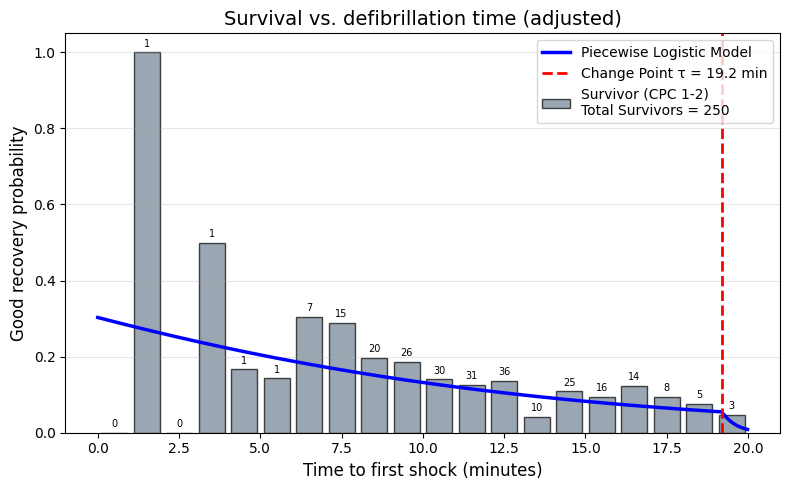

In [23]:
# ==========================================
# 1. Create 1‑minute bins for observed data
# ==========================================
max_time = df_clean['Time_to_Defib_Corrected'].max()
bins = np.arange(0, max_time + 1, 1)
df_clean['Time_Bin'] = pd.cut(df_clean['Time_to_Defib_Corrected'], bins=bins, right=False)

binned_stats = (
    df_clean.groupby('Time_Bin', observed=False)['Outcome_Strict']
    .agg(['count', 'sum'])
    .reset_index()
)
binned_stats['Bin_Mid'] = binned_stats['Time_Bin'].apply(lambda x: x.mid).astype(float)
binned_stats = binned_stats[binned_stats['count'] > 0]

# ==========================================
# 2. Create figure and add bars
# ==========================================
plt.figure(figsize=(8, 5))

# Bars: width slightly less than 1 to avoid overlap
bars = plt.bar(binned_stats['Bin_Mid'],
               binned_stats['sum'] / binned_stats['count'],
               width=0.8, color='slategray', alpha=0.7, edgecolor='black',
               label='Survivor (CPC 1‑2)\nTotal Survivors = 250')

total_survivors = binned_stats['sum'].sum()
print(f"Total survivors across bins: {total_survivors}")
print("Survivors per bin:")
for idx, row in binned_stats.iterrows():
    print(f"  Bin {row['Bin_Mid']:.1f} min: surv = {int(row['sum'])}")

# Assert that total matches expected 250
assert total_survivors == 250, f"Expected 250 survivors, but got {total_survivors}. Check bin edges."

# Add survivor labels on bars (vertical)
for bar, surv in zip(bars, binned_stats['sum']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{int(surv)}', ha='center', va='bottom', fontsize=7)

# Verify total survivors
print(f"Total survivors in df_clean: {df_clean['Outcome_Strict'].sum()}")
print(f"Total survivors in binned_stats: {binned_stats['sum'].sum()}")
assert df_clean['Outcome_Strict'].sum() == binned_stats['sum'].sum(), "Mismatch: binning lost or duplicated survivors"

# ==========================================
# 3. Add fitted adjusted piecewise curve
# ==========================================
time_grid = np.linspace(0, max_time, 200)

# Covariates set to their mean values (scaled already)
cov_means = df_clean[covariates_scaled].mean().values

# Build feature matrix: early term, late term, and covariates (mean for all points)
X_grid = np.column_stack([
    np.clip(time_grid, a_min=None, a_max=optimal_tau),
    np.clip(time_grid - optimal_tau, a_min=0, a_max=None),
    np.tile(cov_means, (len(time_grid), 1))   # same mean covariates for each time point
])

# Apply the same scaler used for the final model (fitted on training data)
X_grid_scaled = scaler_final.transform(X_grid)

# Get predicted probabilities directly from the model
pred_probs = final_model.predict_proba(X_grid_scaled)[:, 1]

plt.plot(time_grid, pred_probs, 'b-', linewidth=2.5,
         label='Piecewise Logistic Model')
plt.axvline(x=optimal_tau, color='red', linestyle='--', linewidth=2,
            label=f'Change Point τ = {optimal_tau:.1f} min')

# ==========================================
# 4. Labels, legend, and display
# ==========================================
plt.xlabel('Time to first shock (minutes)', fontsize=12)
plt.ylabel('Good recovery probability', fontsize=12)
plt.title('Survival vs. defibrillation time (adjusted)', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.ylim(0, max(binned_stats['sum'] / binned_stats['count']) + 0.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('V4_Adjusted_Piecewise_Curve.png', dpi=300)
plt.show()